In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [3]:
data = pd.read_csv("drug200.csv")

In [4]:
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [6]:
X = data.drop("Drug", axis=1)
y = data["Drug"]

In [7]:
categorical = ["Sex", "BP", "Cholesterol"]
numerical = ["Age", "Na_to_K"]

In [8]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(drop="first"), categorical)
])

In [9]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
scores = cross_val_score(pipeline, X, y, cv=skf, scoring="accuracy")

print("Accuracy for each fold:", scores)
print("Average Accuracy:", np.mean(scores))
print("Standard Deviation:", np.std(scores))

Accuracy for each fold: [1.    0.85  0.825 0.85  0.85 ]
Average Accuracy: 0.875
Standard Deviation: 0.0632455532033676


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

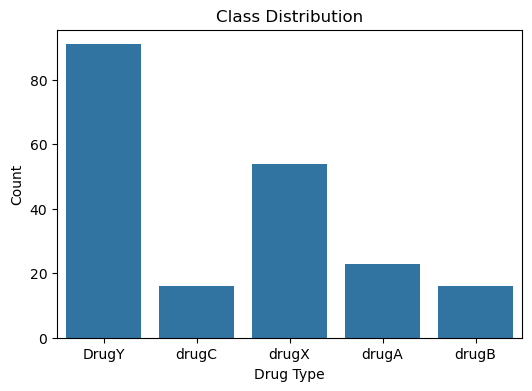

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Drug Type")
plt.ylabel("Count")
plt.show()

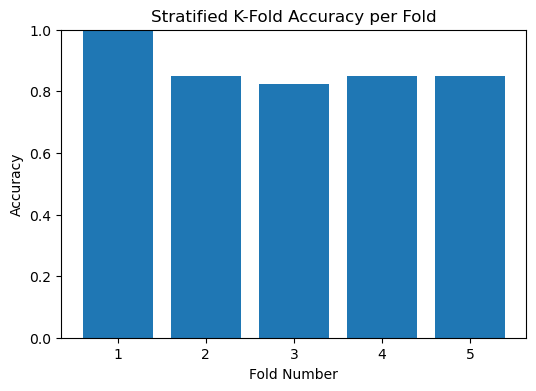

In [15]:
folds = range(1, len(scores)+1)

plt.figure(figsize=(6,4))
plt.bar(folds, scores)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Stratified K-Fold Accuracy per Fold")
plt.ylim(0, 1)
plt.show()